In [1]:
# !pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-04-20 06:22:56.279866: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-20 06:22:56.954496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745130177.234750   16199 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745130177.316298   16199 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745130177.891876   16199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# prompt: how to download this notebook



In [3]:
dataset_train_file_path_leaf = r"/storage/dataset/train"
dataset_val_file_path_leaf = r"/storage/dataset/val"
dataset_test_file_path_leaf = r"/storage/dataset/test"

date = "20April"
model_path = fr"/storage/model/{date}"

val_accuracy_path = model_path + "/" + r"model_val_accuracy_lite_{epoch:02d}-{val_accuracy:.2f}.keras"
val_loss_path =  model_path + "/" + r"model_val_loss_lite_{epoch:02d}-{val_loss:.2f}.keras"
json_history_path = model_path + "/" + r"history.json"

image_width = 299
image_height = 299
batch_size = 16
epoches = 140

In [4]:
data_argumentation_layer = tf.keras.Sequential([
      tf.keras.layers.Rescaling(1./255),
      tf.keras.layers.RandomFlip("HORIZONTAL_AND_VERTICAL"),
      tf.keras.layers.RandomRotation(0.9),
      tf.keras.layers.RandomZoom(0.5),
      tf.keras.layers.RandomContrast(0.9)
])

2025-04-20 06:23:09.932158: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (34)


In [5]:
dataset_train = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_train_file_path_leaf,
    labels="inferred",
    label_mode="categorical",
    seed=123,
    image_size=(image_width, image_height),
    batch_size=batch_size
)

dataset_train = dataset_train.map(lambda x, y: (data_argumentation_layer(x), y))
dataset_train

Found 5487 files belonging to 80 classes.


<_MapDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 80), dtype=tf.float32, name=None))>

In [6]:
dataset_val = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_val_file_path_leaf,
    labels="inferred",
    label_mode="categorical",
    seed=123,
    image_size=(image_width, image_height),
    batch_size=batch_size
)

dataset_val = dataset_val.map(lambda x, y: (data_argumentation_layer(x), y))
dataset_val

Found 689 files belonging to 80 classes.


<_MapDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 80), dtype=tf.float32, name=None))>

In [7]:
dataset_test = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_test_file_path_leaf,
    labels="inferred",
    label_mode="categorical",
    seed=123,
    image_size=(image_width, image_height),
    batch_size=batch_size
)

dataset_test = dataset_test.map(lambda x, y: (data_argumentation_layer(x), y))
dataset_test

Found 724 files belonging to 80 classes.


<_MapDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 80), dtype=tf.float32, name=None))>

In [8]:
base_model = tf.keras.applications.inception_v3.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape = (299, 299, 3)
)

In [9]:
for layer in base_model.layers:
  layer.trainable = False
for layer in base_model.layers[-30:]:
  layer.trainable = True

In [10]:
from tensorflow.keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
output = Dense(80, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,003,760 (87.75 MB)

 Trainable params: 6,357,008 (24.25 MB)

 Non-trainable params: 16,646,752 (63.50 MB)

In [11]:
from tensorflow.keras.metrics import CategoricalAccuracy
model.compile(optimizer="sgd",
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
import json
import os
from tensorflow.keras.callbacks import Callback, ModelCheckpoint

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint1 = ModelCheckpoint(val_accuracy_path, monitor='accuracy', verbose=2, save_best_only=True, mode='max')

callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=val_loss_path,
        monitor='val_loss', save_best_only=True, verbose=2),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50,verbose=2),
    checkpoint1,
]

In [14]:
history = model.fit(dataset_train, validation_data=dataset_val,callbacks=callbacks_list, epochs=epoches)

Epoch 1/140
 46/343 ━━━━━━━━━━━━━━━━━━━━ 3:27 699ms/step - accuracy: 0.0088 - loss: 4.4462

Corrupt JPEG data: premature end of data segment


 92/343 ━━━━━━━━━━━━━━━━━━━━ 2:52 687ms/step - accuracy: 0.0124 - loss: 4.4137

Corrupt JPEG data: 445 extraneous bytes before marker 0xd9


151/343 ━━━━━━━━━━━━━━━━━━━━ 2:09 676ms/step - accuracy: 0.0199 - loss: 4.3802

...

 95/343 ━━━━━━━━━━━━━━━━━━━━ 2:23 578ms/step - accuracy: 0.9818 - loss: 0.0565

Corrupt JPEG data: 445 extraneous bytes before marker 0xd9


134/343 ━━━━━━━━━━━━━━━━━━━━ 2:01 580ms/step - accuracy: 0.9827 - loss: 0.0536

Corrupt JPEG data: premature end of data segment


343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9832 - loss: 0.0514  
Epoch 140: val_loss did not improve from 0.16856

Epoch 140: accuracy did not improve from 0.98578
343/343 ━━━━━━━━━━━━━━━━━━━━ 222s 645ms/step - accuracy: 0.9832 - loss: 0.0514 - val_accuracy: 0.9478 - val_loss: 0.2196


46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 503ms/step - accuracy: 0.9361 - loss: 0.2520
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 56

2025-04-20 15:41:20.158261: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


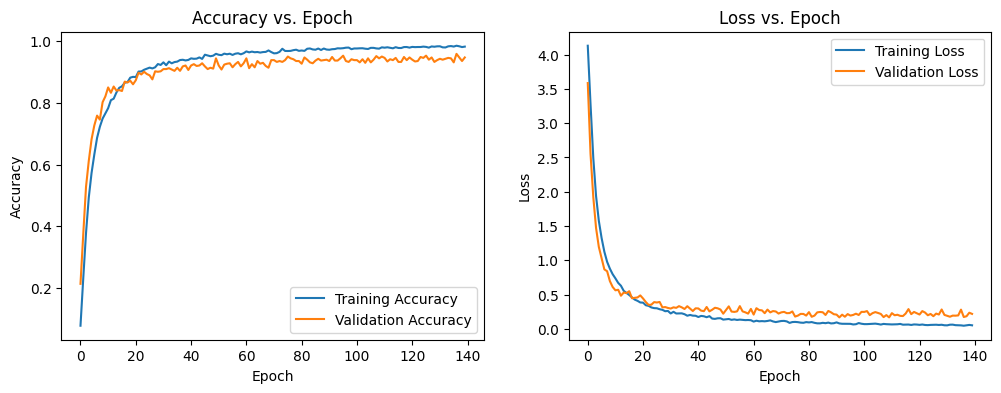

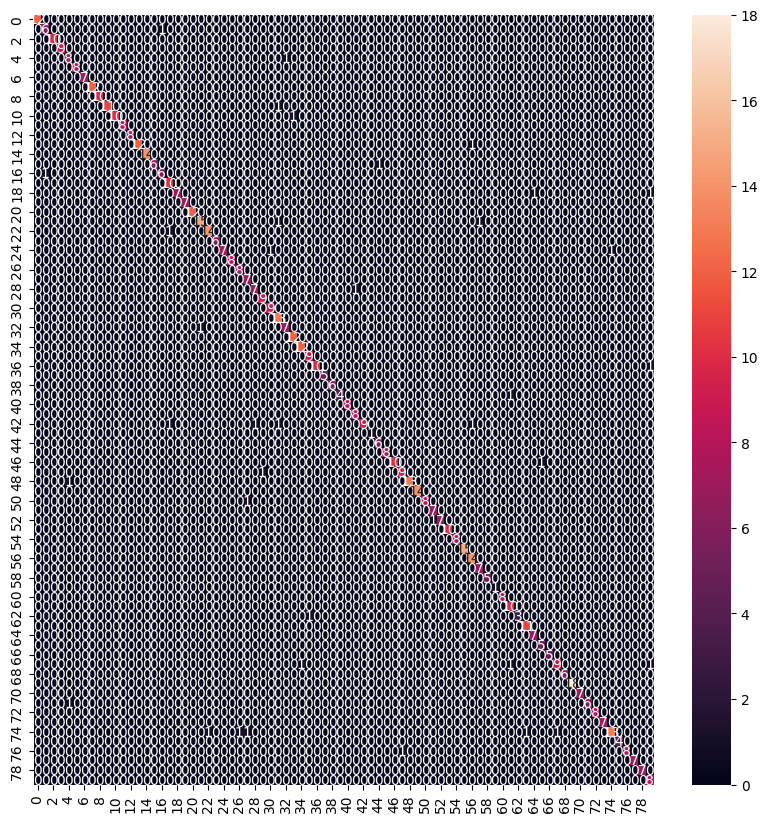

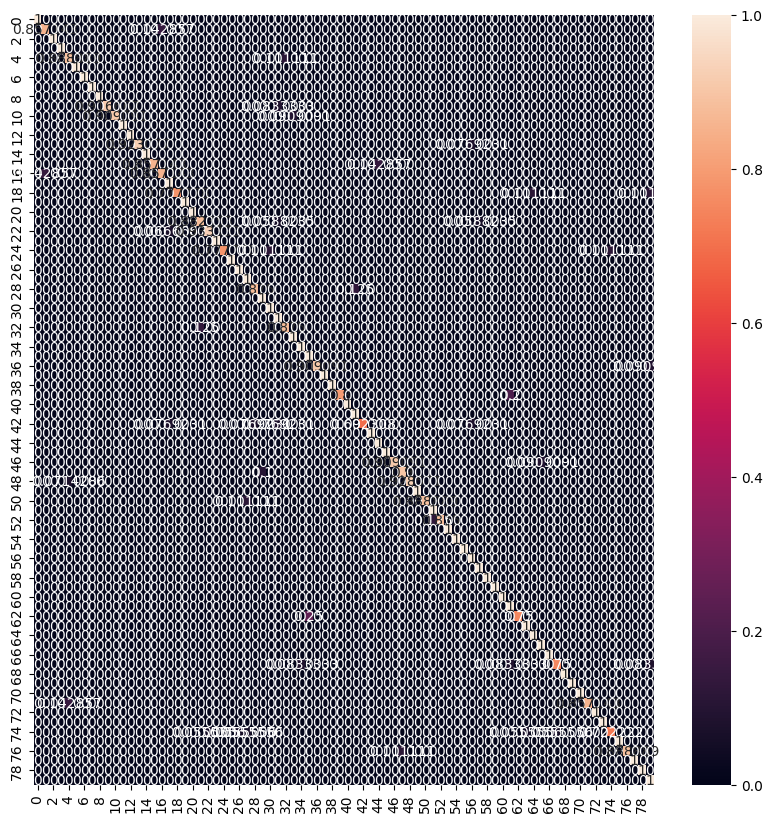

In [15]:
# prompt: write code to save all type of required graph, visuals and data for futher research of history variable, histoiry is not saved as json directly use it
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs. Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs. Epoch')
plt.savefig(fr"{model_path}/training_history.png") #Save the plot

# Save model architecture
with open(fr"{model_path}/model_architecture.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))


# Evaluate the model and save results
loss, accuracy = model.evaluate(dataset_test)
evaluation_results = {"loss": loss, "accuracy": accuracy}
with open(fr"{model_path}/evaluation_results.json", "w") as f:
    json.dump(evaluation_results, f)


y_true = []
y_pred = []
for images, labels in dataset_test:
  y_true.extend(np.argmax(labels, axis=1))
  predictions = model.predict(images)
  y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
row_sums = cm.sum(axis=1, keepdims=True)
norm_conf_mx = cm / row_sums
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt='g')
plt.savefig(fr"{model_path}/confusion_matrix.png")
plt.figure(figsize=(10,10))
sns.heatmap(norm_conf_mx, annot=True, fmt='g')
plt.savefig(fr"{model_path}/confusion_matrix_norm.png")